# GTSRB Dataset Overview

Notebook này trình bày tổng quan về bộ dữ liệu **German Traffic Sign Recognition Benchmark – GTSRB**.

Nội dung gồm:

- Đọc thông tin tập train và test.
- Thống kê số lượng ảnh và số lớp.
- Phân tích phân bố lớp.
- Phân tích kích thước ảnh.
- Hiển thị một số ảnh mẫu.

In [2]:
!mkdir -p ./data

!wget -nc -P ./data \
https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip

!wget -nc -P ./data \
https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip

!wget -nc -P ./data \
https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_GT.zip

!unzip -q -n ./data/GTSRB_Final_Training_Images.zip -d ./data
!unzip -q -n ./data/GTSRB_Final_Test_Images.zip -d ./data
!unzip -q -n ./data/GTSRB_Final_Test_GT.zip -d ./data

print("Dataset downloaded and extracted successfully.")

--2026-07-14 02:26:20--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Training_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 276294756 (263M) [application/zip]
Saving to: ‘./data/GTSRB_Final_Training_Images.zip’

GTSRB_Final_Trainin 100%[===================>] 263.50M  10.2MB/s    in 29s     

2026-07-14 02:26:51 (8.94 MB/s) - ‘./data/GTSRB_Final_Training_Images.zip’ saved [276294756/276294756]

--2026-07-14 02:26:52--  https://sid.erda.dk/public/archives/daaeac0d7ce1152aea9b61d9f1e19370/GTSRB_Final_Test_Images.zip
Resolving sid.erda.dk (sid.erda.dk)... 130.225.104.13
Connecting to sid.erda.dk (sid.erda.dk)|130.225.104.13|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 88978620 (85M) [application/zip]
Saving to: ‘./data/GTSRB_Final_Test_Images.zip’

GTSRB_Final_Test_Im 100%[======

## 1. Load Dataset Annotations

GTSRB có 43 lớp biển báo giao thông.

Training set được chia thành 43 thư mục. Mỗi thư mục chứa ảnh và một file CSV annotation.

Test set sử dụng một file annotation chung có tên `GT-final_test.csv`.

In [3]:
import os
import glob
import cv2
import pandas as pd
import matplotlib.pyplot as plt

TRAIN_DIR = "./data/GTSRB/Final_Training/Images"
TEST_DIR = "./data/GTSRB/Final_Test/Images"

In [4]:
# Đọc annotation của training set
train_csv_files = sorted(
    glob.glob(os.path.join(TRAIN_DIR, "*", "GT-*.csv"))
)

train_frames = []

for csv_path in train_csv_files:
    class_folder = os.path.dirname(csv_path)

    class_df = pd.read_csv(csv_path, sep=";")

    class_df["ImagePath"] = class_df["Filename"].apply(
        lambda filename: os.path.join(class_folder, filename)
    )

    train_frames.append(class_df)

train_df = pd.concat(train_frames, ignore_index=True)

print("Training shape:", train_df.shape)
train_df.head()

Training shape: (39209, 9)


,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,ImagePath
0,00000_00000.ppm,29,30,5,6,24,25,0,./data/GTSRB/Final_Training/Images/00000/00000...
1,00000_00001.ppm,30,30,5,5,25,25,0,./data/GTSRB/Final_Training/Images/00000/00000...
2,00000_00002.ppm,30,30,5,5,25,25,0,./data/GTSRB/Final_Training/Images/00000/00000...
3,00000_00003.ppm,31,31,5,5,26,26,0,./data/GTSRB/Final_Training/Images/00000/00000...
4,00000_00004.ppm,30,32,5,6,25,26,0,./data/GTSRB/Final_Training/Images/00000/00000...


In [5]:
# Đọc annotation của test set
test_gt_path = glob.glob(
    "./data/**/GT-final_test.csv",
    recursive=True
)[0]

test_df = pd.read_csv(test_gt_path, sep=";")

test_df["ImagePath"] = test_df["Filename"].apply(
    lambda filename: os.path.join(TEST_DIR, filename)
)

print("Test shape:", test_df.shape)
test_df.head()

Test shape: (12630, 9)


,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId,ImagePath
0,00000.ppm,53,54,6,5,48,49,16,./data/GTSRB/Final_Test/Images/00000.ppm
1,00001.ppm,42,45,5,5,36,40,1,./data/GTSRB/Final_Test/Images/00001.ppm
2,00002.ppm,48,52,6,6,43,47,38,./data/GTSRB/Final_Test/Images/00002.ppm
3,00003.ppm,27,29,5,5,22,24,33,./data/GTSRB/Final_Test/Images/00003.ppm
4,00004.ppm,60,57,5,5,55,52,11,./data/GTSRB/Final_Test/Images/00004.ppm


## 2. Dataset Summary

Phần này thống kê số lượng ảnh và số lớp của training set, test set và toàn bộ dataset.

In [6]:
dataset_summary = pd.DataFrame({
    "Dataset": [
        "Training set",
        "Test set",
        "Complete dataset"
    ],
    "Number of images": [
        len(train_df),
        len(test_df),
        len(train_df) + len(test_df)
    ],
    "Number of classes": [
        train_df["ClassId"].nunique(),
        test_df["ClassId"].nunique(),
        train_df["ClassId"].nunique()
    ]
})

dataset_summary

,Dataset,Number of images,Number of classes
0,Training set,39209,43
1,Test set,12630,43
2,Complete dataset,51839,43


## 3. Class Distribution

GTSRB có 43 lớp nhưng số lượng ảnh giữa các lớp không bằng nhau.

Biểu đồ phân bố lớp giúp xác định mức độ mất cân bằng dữ liệu. Những lớp có nhiều ảnh hơn có thể ảnh hưởng mạnh hơn đến quá trình huấn luyện mô hình.

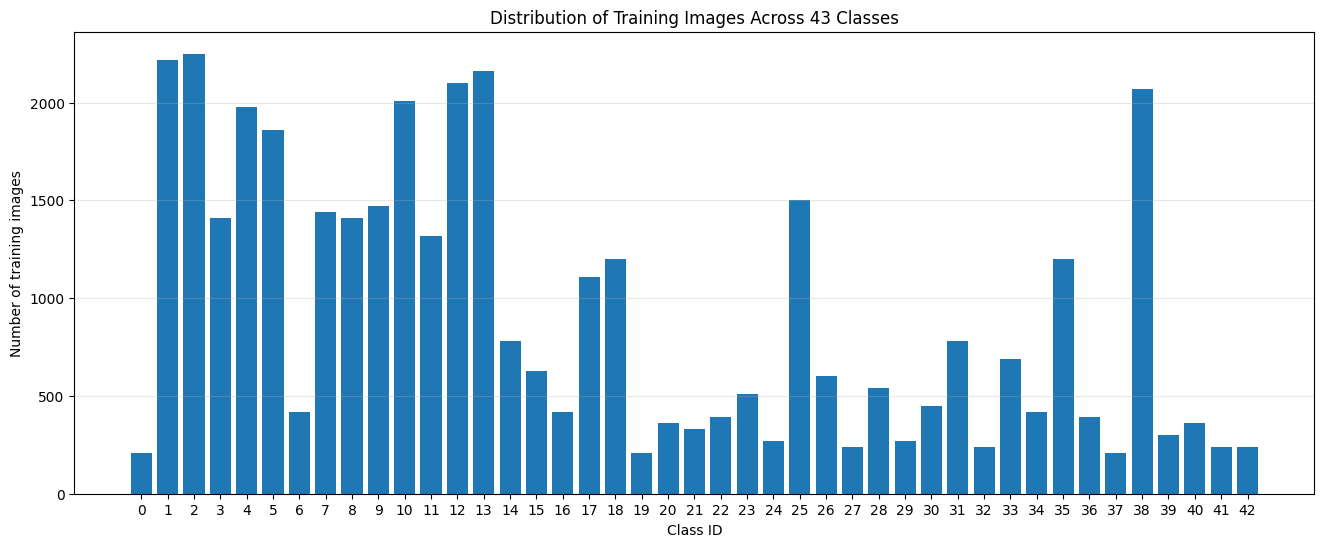

In [7]:
class_distribution = (
    train_df["ClassId"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(16, 6))

plt.bar(
    class_distribution.index,
    class_distribution.values
)

plt.xlabel("Class ID")
plt.ylabel("Number of training images")
plt.title("Distribution of Training Images Across 43 Classes")

plt.xticks(range(43))
plt.grid(axis="y", alpha=0.3)

plt.show()

In [8]:
print("Class with the fewest images:")
print("Class ID:", class_distribution.idxmin())
print("Number of images:", class_distribution.min())

print("\nClass with the most images:")
print("Class ID:", class_distribution.idxmax())
print("Number of images:", class_distribution.max())

print(
    "\nImbalance ratio:",
    round(
        class_distribution.max()
        / class_distribution.min(),
        2
    )
)

Class with the fewest images:
Class ID: 0
Number of images: 210

Class with the most images:
Class ID: 2
Number of images: 2250

Imbalance ratio: 10.71


## 4. Image Dimension Analysis

Các ảnh trong GTSRB có chiều rộng và chiều cao khác nhau.

Điều này xảy ra vì biển báo được chụp ở nhiều khoảng cách, góc nhìn và điều kiện ánh sáng khác nhau.

Do kích thước ảnh không cố định, ảnh cần được resize về cùng kích thước trong bước tiền xử lý.

In [9]:
train_df[["Width", "Height"]].describe()

,Width,Height
count,39209.000000,39209.000000
mean,50.835880,50.328930
std,24.306933,23.115423
min,25.000000,25.000000
25%,35.000000,35.000000
50%,43.000000,43.000000
75%,58.000000,58.000000
max,243.000000,225.000000


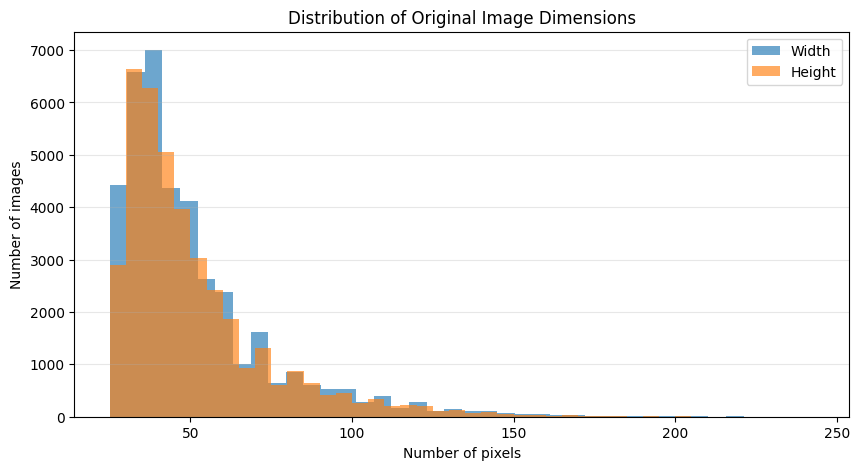

In [10]:
plt.figure(figsize=(10, 5))

plt.hist(
    train_df["Width"],
    bins=40,
    alpha=0.65,
    label="Width"
)

plt.hist(
    train_df["Height"],
    bins=40,
    alpha=0.65,
    label="Height"
)

plt.xlabel("Number of pixels")
plt.ylabel("Number of images")
plt.title("Distribution of Original Image Dimensions")

plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Sample Images

Phần này hiển thị một số ảnh ngẫu nhiên trong training set.

Các ảnh cho thấy sự khác nhau về loại biển báo, kích thước, độ sáng, góc nhìn và chất lượng hình ảnh.

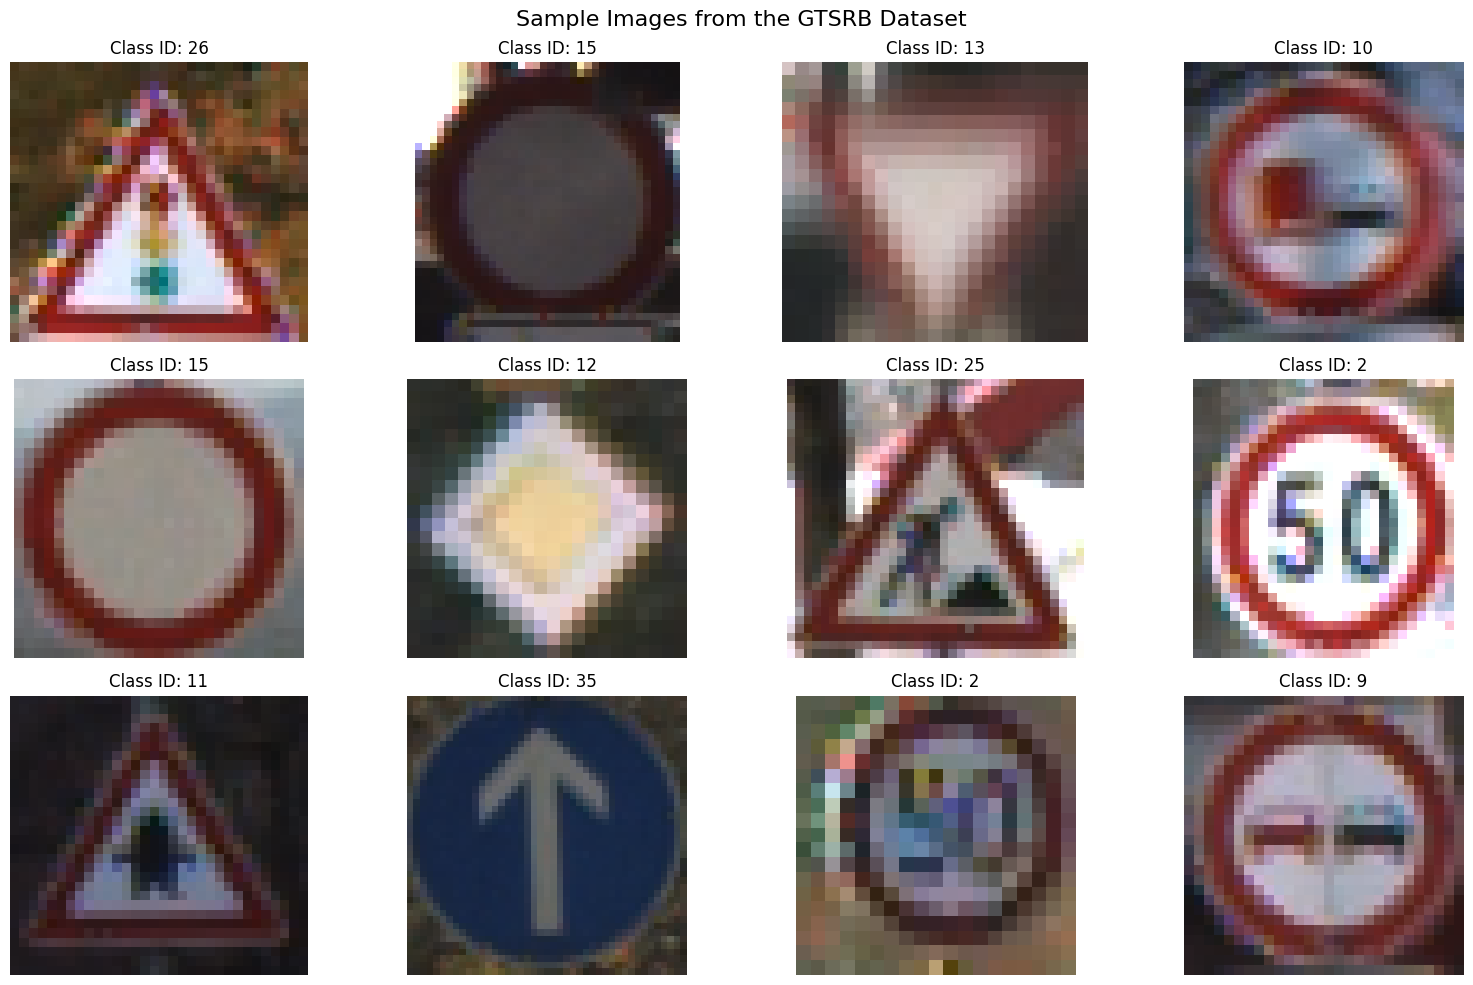

In [11]:
sample_df = train_df.sample(
    n=12,
    random_state=42
)

plt.figure(figsize=(16, 10))

for position, (_, row) in enumerate(
    sample_df.iterrows(),
    start=1
):
    image = cv2.imread(row["ImagePath"])

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    # Crop vùng chứa biển báo để hiển thị rõ hơn
    x1 = int(row["Roi.X1"])
    y1 = int(row["Roi.Y1"])
    x2 = int(row["Roi.X2"])
    y2 = int(row["Roi.Y2"])

    roi_image = image[
        y1:y2 + 1,
        x1:x2 + 1
    ]

    plt.subplot(3, 4, position)

    plt.imshow(roi_image)

    plt.title(
        f"Class ID: {row['ClassId']}"
    )

    plt.axis("off")

plt.suptitle(
    "Sample Images from the GTSRB Dataset",
    fontsize=16
)

plt.tight_layout()
plt.show()

## 6. Dataset Overview Conclusion

The GTSRB dataset contains 51,839 traffic sign images belonging to 43 classes.

The training set contains 39,209 images, while the official test set contains 12,630 images.

The exploratory analysis shows that:

- The dataset contains 43 traffic sign categories.
- The classes do not contain equal numbers of images.
- The original images have different widths and heights.
- Traffic signs were captured under different viewing and lighting conditions.
- The dataset therefore requires image preprocessing before feature extraction and model training.

In the next stage, the Region of Interest will be cropped, resized to a fixed size, converted to grayscale, and used for HOG feature extraction.